In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial
from scipy.optimize import minimize

# Принадлежность параметрическому семейству

Вариант: буква а, ii

1. Реализовать сложные критерии а) Колмогорова принадлежности ii) экспоненциальному закону, используя метод Монте-Карло для вычисления предельного распределения p-value. Построить ЭФР p-value при гипотезе и при альтернативе, моделируя данные из распределения Стьюдента t5 в первом случае и χ^2_2 во втором.

In [9]:
def ks_stat(data, f0):
  data.sort()
  n = len(data)
  stat = 0
  for i in range(n):
    stat = max(stat, abs(f0(data[i]) - i/n), abs(f0(data[i]) - (i+1)/n))
  return stat*np.sqrt(n)


def ks_par_stat(data):
  n = len(data)
  loc_mle = np.min(data)
  scale_mle = (np.mean(data) - loc_mle)

  def fitted_cdf(x):
        return stats.expon.cdf(x, loc=loc_mle, scale=scale_mle)
  stat = ks_stat(data, fitted_cdf)
  return stat

def ks_par_montecarlo(N = 1000, n = 1000):
  T = []
  for _ in range(N):
    x_data = stats.expon.rvs(loc = 0, scale = 1, size = n)
    T.append(ks_par_stat(x_data))
  return sorted(T)

def ks_par_pval(x_data, T):
  N = len(T)
  stat = ks_par_stat(x_data)
  k = 0
  for i in range(N):
    if T[i] < stat:
      k+=1
    else:
      break
  pval = 1 - k/N
  return stat, pval

In [15]:
#НЕ ЗАПУСКАТЬ
T_ks_par = ks_par_montecarlo()

In [18]:
#НЕ ЗАПУСКАТЬ
with open('ks_par_mc.txt', 'w') as f:
    f.write('\n'.join(map(str, T_ks_par)))

In [7]:
with open('ks_par_mc.txt', 'r') as f:
    T_ks_par_file = [float(line.strip()) for line in f if line.strip()]

In [ ]:
#hypothesis
k = 1000
n = 100
a = 0.05

p_val = []
acceptance = 0
for i in range(k):
  l = 3
  s = 0.5
  x_data = stats.expon.rvs(loc = l, scale= s, size = n)
  pval = ks_par_pval(x_data, T_ks_par_file)[1]
  p_val.append(pval)
  if pval >= a:
    acceptance += 1/k
sns.ecdfplot(p_val, label=f'Exp(loc = {l}, scale = {s}), acc = {acceptance:.3f}')


#alternative
acceptance = 0
p_val = []
for i in range(k):
  x_data = stats.chi2.rvs(df=3, size = n)
  pval = ks_par_pval(x_data, T_ks_par_file)[1]
  p_val.append(pval)
  if pval >= a:
    acceptance += 1/k
sns.ecdfplot(p_val, label = f'Chi2_3, acc = {acceptance:.3f}')


x = np.linspace(0,1,1000)
plt.plot(x,x, linestyle = '--', color = 'black')
plt.legend()
plt.show()

NameError: name 'ks_par_pval' is not defined

2. Реализовать критерий хи-квадрат для проверки  ii) экспоненциальности (ОМП по сгруппированным данным находить численно). Для разбиения на промежутки использовать следующие подходы: 1) делим так, чтобы в ячейки попадало поровну наблюдений, 2) берем квантили уровней i/k теоретического распределения, в качестве неизвестного параметра используем ОМП. Для подсчета p-value использовать предельное распределение.

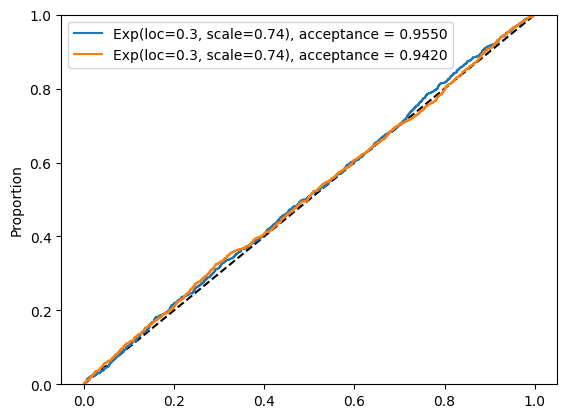

In [ ]:
def chi2_exp(x_data, sections):
    #sections = 1 or 2
    x_data.sort()
    n = len(x_data)
    k = int(np.log2(n))

    if sections == 1:
        quantiles = [-np.inf]
        s = int(n/k)
        for i in range(1,k):
            quantiles.append((x_data[i*s - 1] + x_data[i*s])/2)
        quantiles.append(np.inf)
    elif sections == 2:
        loc_mle = x_data[0] # = min(x_data)
        scale_mle = np.mean(x_data) - loc_mle
        quantiles = [-np.inf]
        for i in range(1,k):
            quantiles.append(stats.expon.ppf(i/k, loc = loc_mle, scale = scale_mle))
        quantiles.append(np.inf)
    else:
        print('sections??')
        return

    counts, bin_edges = np.histogram(x_data, bins=quantiles)

    #counting mle
    def L(vars):
        loc, scale = vars
        l = (1 - np.exp(-(quantiles[1]-loc)/scale))**counts[0]
        for i in range(1, len(quantiles)-2):
            l *= (np.exp(-(quantiles[i]-loc)/scale) - np.exp(-(quantiles[i+1]-loc)/scale))**counts[i]
        l *= (np.exp(-(quantiles[-2] - loc)/scale))**counts[-1]
        return -l

    loc_mle = x_data[0]
    scale_mle = np.mean(x_data) - loc_mle

    result = minimize(L, [loc_mle, scale_mle])
    loc_mle_gr = result.x[0]
    scale_mle_gr = result.x[1]

    #getting statistic

    expected = [(1 - np.exp(-(quantiles[1]-loc_mle_gr)/scale_mle_gr))*n]
    for i in range(1, len(quantiles)-2):
        expected.append((np.exp(-(quantiles[i]-loc_mle_gr)/scale_mle_gr) - np.exp(-(quantiles[i+1]-loc_mle_gr)/scale_mle_gr))*n)
    expected.append((np.exp(-(quantiles[-2] - loc_mle_gr)/scale_mle_gr))*n)

    stat, pval = stats.chisquare(counts, expected, ddof = 1)

    return stat, pval


#testing for hypothesis

k = 1000
n = 1000
a = 0.05

l = 0.3
s = 0.74

p_val_1 = []
p_val_2 = []
acc_1 = 0
acc_2 = 0

for _ in range(k):
    x_data = stats.expon.rvs(loc = l, scale = s, size = n)
    pval_1 = chi2_exp(x_data, 1)[1]
    pval_2 = chi2_exp(x_data, 2)[1]
    p_val_1.append(pval_1)
    p_val_2.append(pval_2)
    if pval_1 >= 0.05:
        acc_1+= 1/k
    if pval_2 >= 0.05:
        acc_2 += 1/k

x = np.linspace(0,1,1000)
plt.plot(x,x, linestyle = '--', color = 'black')
sns.ecdfplot(p_val_1, label=f'Exp(loc={l}, scale={s}), acceptance = {acc_1:.4f}')
sns.ecdfplot(p_val_2, label=f'Exp(loc={l}, scale={s}), acceptance = {acc_2:.4f}')

plt.legend()
plt.show()


3. Исследовать сгенерированные модельные данные X на нормальность, где

• Xi имеют распределение Вейбулла с параметром формы λ;

• Xi имеют χ2_n распределение, n = 5, 10, 25

• Xi ∼ Binom(n, 1/2).

ii) использовать встроенный критерий Андерсона-Дарлинга
(scipy.stats.anderson), а также критерии Шапиро-Уилко (scipy.stats.shapiro) и Д’Агостино
(scipy.stats.normaltest). Построить ЭФР p-value и график мощности. Подобрать размер выборки так,
чтобы сравнение было осмысленным.

In [2]:
def criterion(pval_gen, data_gen, ax = None, label_custom = None, output = True):
    k = 100
    p_val = []
    a = 0.05
    
    for _ in range(k):
        x_data = data_gen()
        pval = pval_gen(x_data)[1]
        p_val.append(pval)
    
    ecdf = stats.ecdf(p_val)
    if output:
        sns.ecdfplot(p_val, label = label_custom, ax = ax)
    return ecdf.cdf.evaluate(a)



In [3]:
def compare_crit(alternative, title = None):
    #fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    crits = [[partial(stats.anderson, dist='norm', method=stats.MonteCarloMethod(n_resamples = 100)), 'Anderson'], [stats.shapiro, "Shapiro"], [stats.normaltest, 'Normaltest']]
    for crit in crits:
        pval_gen = crit[0]
        label = crit[1]
        power = criterion(pval_gen, alternative, label_custom = label)
    
    x = np.linspace(0,1,1000)
    plt.plot(x,x,linestyle = '--', color='black')
    plt.title(title)
    plt.legend()
    plt.show()



def compare_power(alternative, vals, title = None):
    crits = [[partial(stats.anderson, dist='norm', method=stats.MonteCarloMethod(n_resamples = 100)), 'Anderson'], [stats.shapiro, "Shapiro"], [stats.normaltest, 'Normaltest']]
    for crit in crits:
        pval_gen = crit[0]
        crit_name = crit[1]
        power_mass = []
        for param in vals:
            power = criterion(pval_gen, partial(alternative, param), output= False)
            power_mass.append(power)
        plt.plot(vals, power_mass, marker='o', label = crit_name)
    plt.title(title)
    plt.legend()
    plt.show()

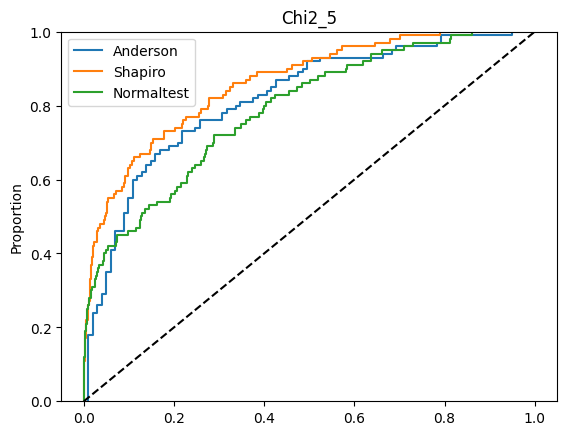

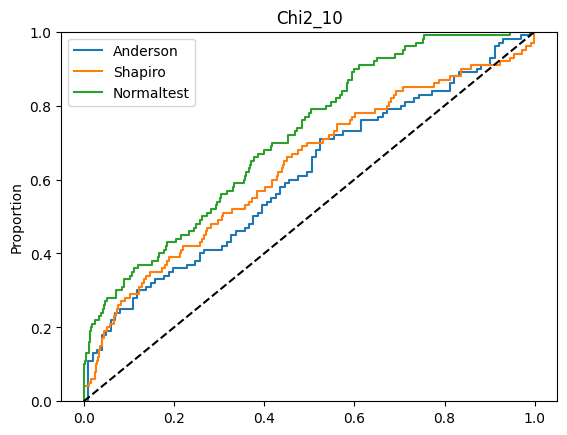

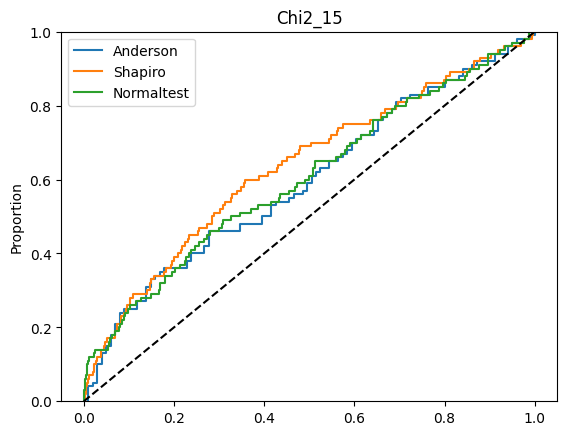

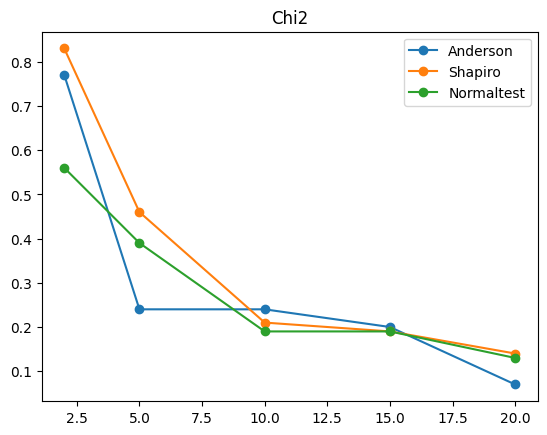

In [ ]:
#Chi2
n_vals = [5, 10, 15]
n_size = 20
for n in n_vals:
    compare_crit(partial(stats.chi2.rvs, df = n, size = n_size), title = f'Chi2_{n}')

vals = [2, 5, 10, 15, 20]
compare_power(partial(stats.chi2.rvs, size = n_size), vals, title = 'Chi2')

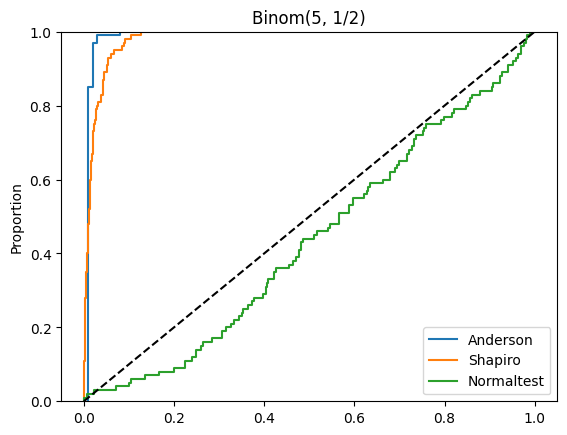

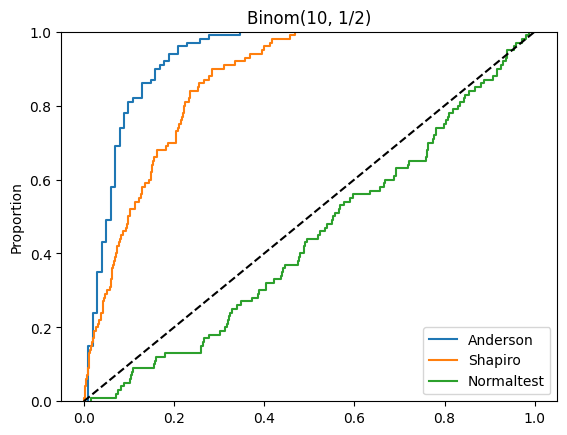

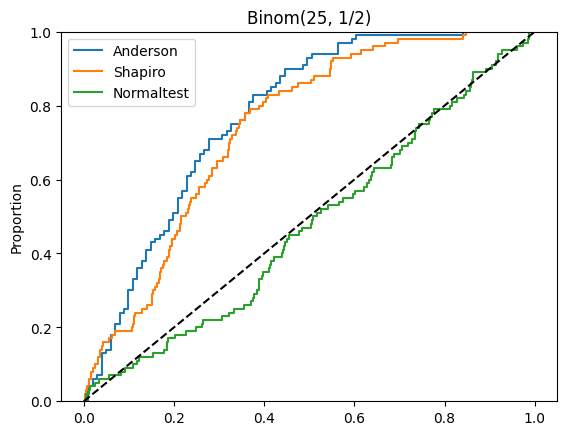

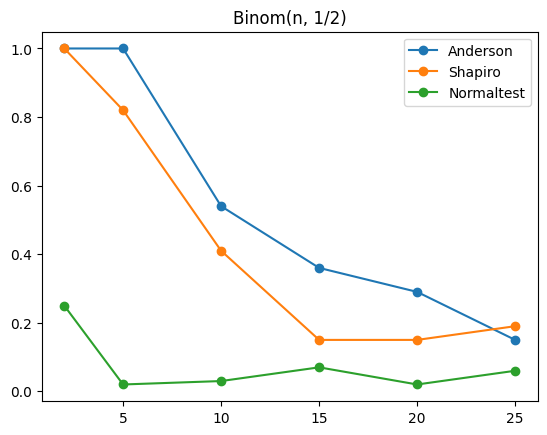

In [18]:
#Binom  partial(stats.binom.rvs, n = n_bin, p =1/2, size = n_size), label_custom = f'Binom({n_bin}, 1/2)')
n_vals = [5, 10, 25]
n_size = 30
for n in n_vals:
    compare_crit(partial(stats.binom.rvs, n, p =1/2, size = n_size), title = f'Binom({n}, 1/2)')

vals = [2, 5, 10, 15, 20, 25]
compare_power(partial(stats.binom.rvs, p=1/2, size = n_size), vals, title = 'Binom(n, 1/2)')

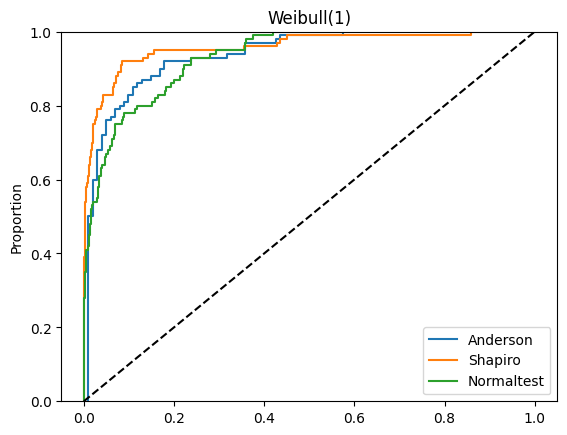

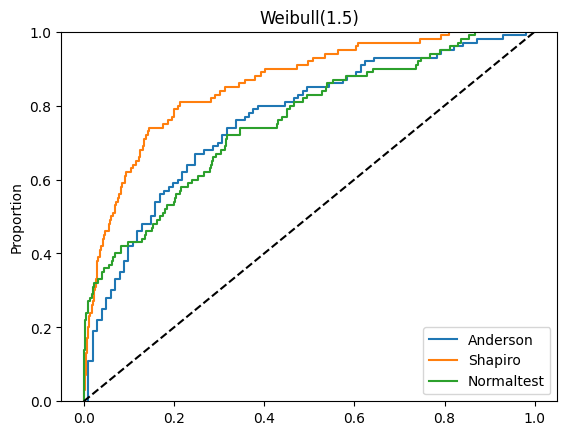

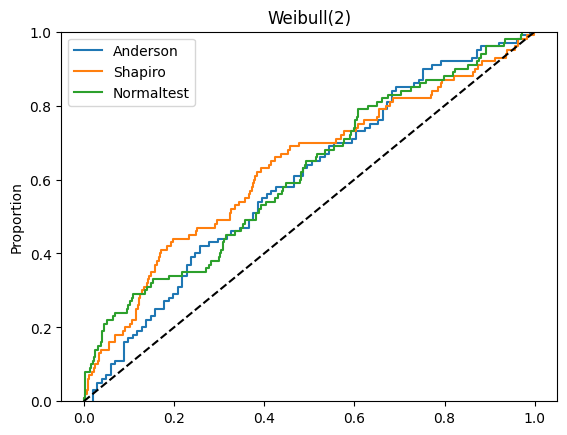

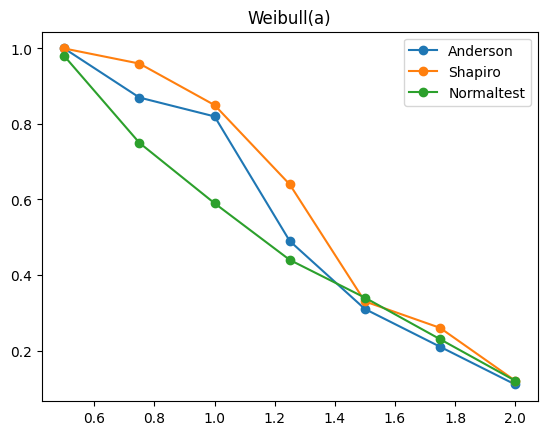

In [21]:
#weibull
#partial(np.random.weibull, a_w, size = n_size), label_custom = f'Weibull({a_w}), n = {n_size}')
a_vals = [ 1,1.5, 2]
n_size = 20
for a_w in a_vals:
    compare_crit(partial(np.random.weibull, a_w, size = n_size), title = f'Weibull({a_w})')

vals = [0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]
compare_power(partial(np.random.weibull, size = n_size),vals,  title = f'Weibull(a)')

In [ ]:
a_vals = [ 1,1.5, 2]
n_size = 20
for a_w in a_vals:
    compare_crit(partial(np.random.laplace, a_w, size = n_size), title = f'Weibull({a_w})')

vals = [0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]
compare_power(partial(np.random.weibull, size = n_size),vals,  title = f'Weibull(a)')

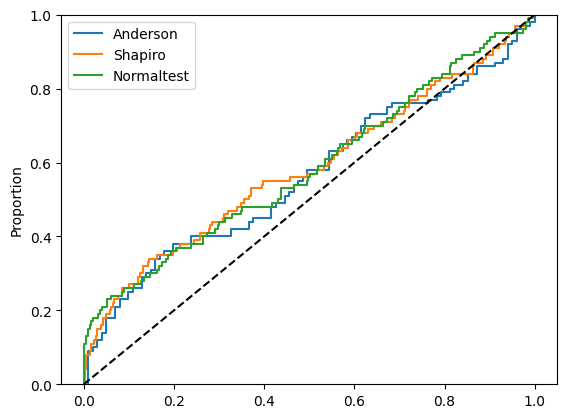

In [6]:
n_size = 10
compare_crit(partial(np.random.laplace, size = n_size))

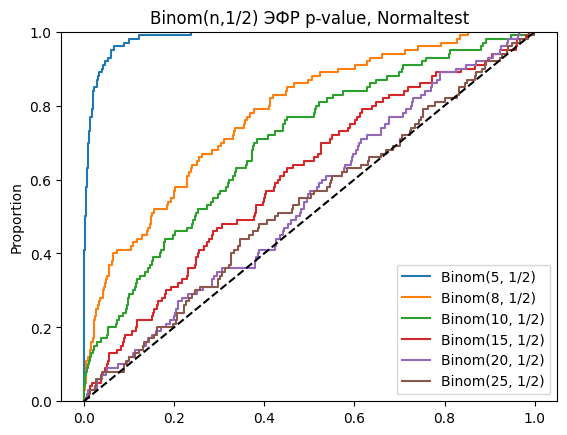

Text(0.5, 1.0, 'Мощность против Binom(n, 1/2), а = 0.05, Normaltest')

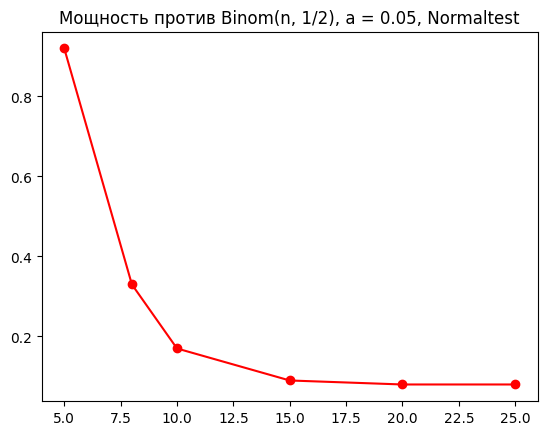

In [24]:
n_vals = [5, 8, 10, 15, 20, 25]
power_mass_bin = []
n_size = 1000
for n_bin in n_vals:
    power = criterion(stats.normaltest, partial(stats.binom.rvs, n = n_bin, p =1/2, size = n_size), label_custom = f'Binom({n_bin}, 1/2)')
    power_mass_bin.append(power)

x = np.linspace(0,1,1000)
plt.plot(x,x, linestyle = '--', color = 'black')
plt.title('Binom(n,1/2) ЭФР p-value, Normaltest')
plt.legend()
plt.show()

plt.plot(n_vals, power_mass_bin, color = 'red', marker='o')
plt.title('Мощность против Binom(n, 1/2), а = 0.05, Normaltest')

4. * Исследовать сгенерированные модельные данные X на экспонециальность, где

(a) Xi имеют распределение |N (μ, 1)|;

Построить ЭФР p-value при фиксированных параметрах и график мощности в зависимости от параметра. Подобрать размер выборки и параметр так, чтобы сравнение было осмысленным. Использовать

ii) критерий из первого пункта, а также критерии а)Шапиро-Уилка

In [ ]:
def criterion(pval_gen, data_gen, label_custom = None):
    k = 100
    p_val = []
    a = 0.05
    
    for _ in range(k):
        x_data = data_gen()
        pval = pval_gen(x_data)[1]
        p_val.append(pval)
    
    ecdf = stats.ecdf(p_val)
    sns.ecdfplot(p_val, label = label_custom)
    x = np.linspace(0,1,1000)
    plt.plot(x,x,linestyle = '--', color='black')
    return ecdf.cdf.evaluate(a)


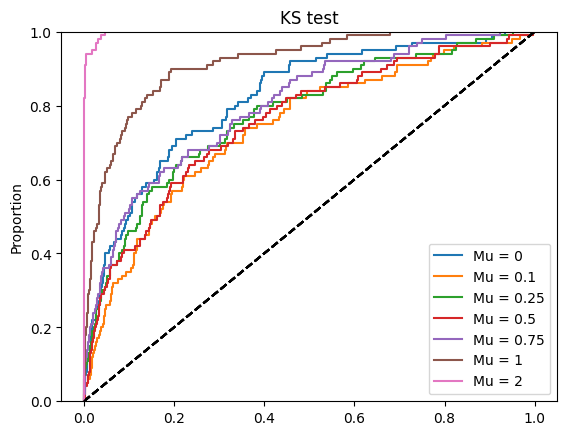

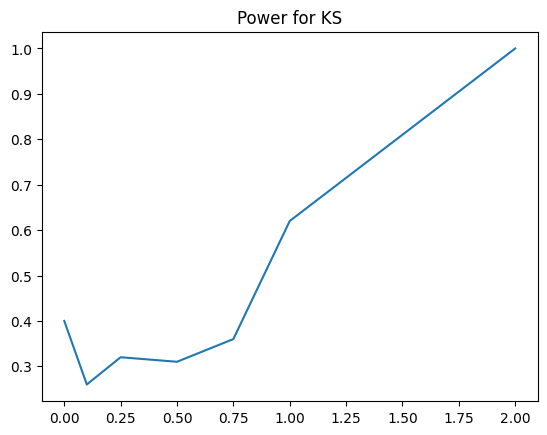

In [25]:
def generator(m, n):
    norm = abs(stats.norm.rvs(m, 1, size=n))
    return norm

#def ks_par_pval(x_data, T):
n = 50
mu_vals = [0, 0.1,0.25, 0.5,0.75, 1, 2]
power_mass = []
for mu in mu_vals:
    power = criterion(partial(ks_par_pval, T = T_ks_par_file), partial(generator, m = mu, n = n), label_custom = f'Mu = {mu}')
    power_mass.append(power)

plt.legend()
plt.title('KS test')
plt.show()

plt.plot(mu_vals, power_mass)
plt.title('Power for KS')
plt.show()


In [ ]:
def shapiro_exp_stat(data):
    n = len(data)
    mean = np.mean(data)
    data_min = np.min(data)
    data_sum = sum([(i- mean)**2 for i in data])
    stat = (n*(mean - data_min)**2)/((n-1)*data_sum)
    return stat

def shapiro_exp_montecarlo(n = 1000, N = 1000):
  T = []
  for i in range(N):
    x_data = stats.expon.rvs(size = n)
    T.append(shapiro_exp_stat(x_data))
  return sorted(T)

def shapiro_exp(x_data, T):
  N = len(T)
  stat = shapiro_exp_stat(x_data)
  k = 0
  for i in range(N):
    if T[i] < stat:
      k+=1
    else:
      break
  pval = 1 - k/N
  return stat, pval

In [34]:
def criterion_shapiro(pval_gen, data_gen, size, label_custom = None):
    k = 100
    p_val = []
    a = 0.05
    
    T = shapiro_exp_montecarlo(n = size)
    
    for _ in range(k):
        x_data = data_gen(n = size)
        pval = pval_gen(x_data, T)[1]
        p_val.append(pval)
    
    ecdf = stats.ecdf(p_val)
    sns.ecdfplot(p_val, label = label_custom)
    x = np.linspace(0,1,1000)
    plt.plot(x,x,linestyle = '--', color='black')
    return ecdf.cdf.evaluate(a)


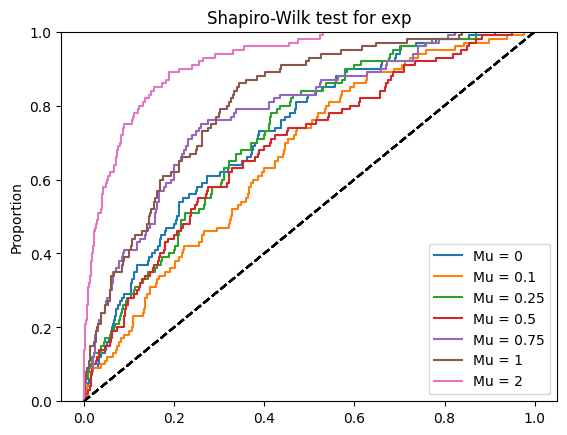

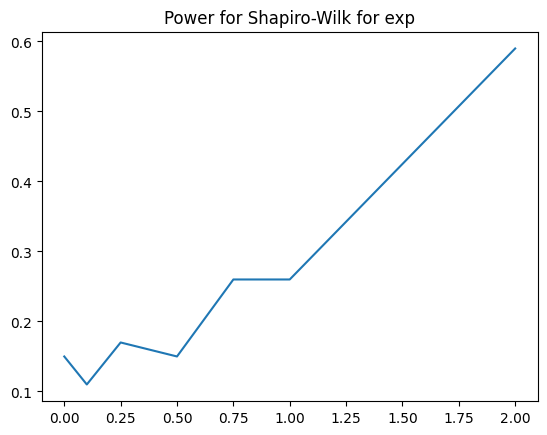

In [36]:
def generator(m, n):
    norm = abs(stats.norm.rvs(m, 1, size=n))
    return norm

n = 10
mu_vals = [0, 0.1,0.25, 0.5,0.75, 1, 2]
power_mass = []
for mu in mu_vals:

    power = criterion_shapiro(shapiro_exp, partial(generator, m = mu),size = n, label_custom = f'Mu = {mu}')
    power_mass.append(power)

plt.title('Shapiro-Wilk test for exp')
plt.legend()
plt.show()

plt.plot(mu_vals, power_mass)
plt.title('Power for Shapiro-Wilk for exp')
plt.show()